In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    LayerNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [2]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\spand\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [3]:
df = pd.read_csv("mtsamples.csv")

print(df.shape)

df.head()

(4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [4]:
df = df[[
    "transcription",
    "medical_specialty"
]]

df.dropna(inplace=True)

df.head()

,transcription,medical_specialty
0,"SUBJECTIVE:, This 23-year-old white female pr...",Allergy / Immunology
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",Bariatrics
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",Bariatrics
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary


In [5]:
print("Number of Reports")

print(len(df))

Number of Reports
4966


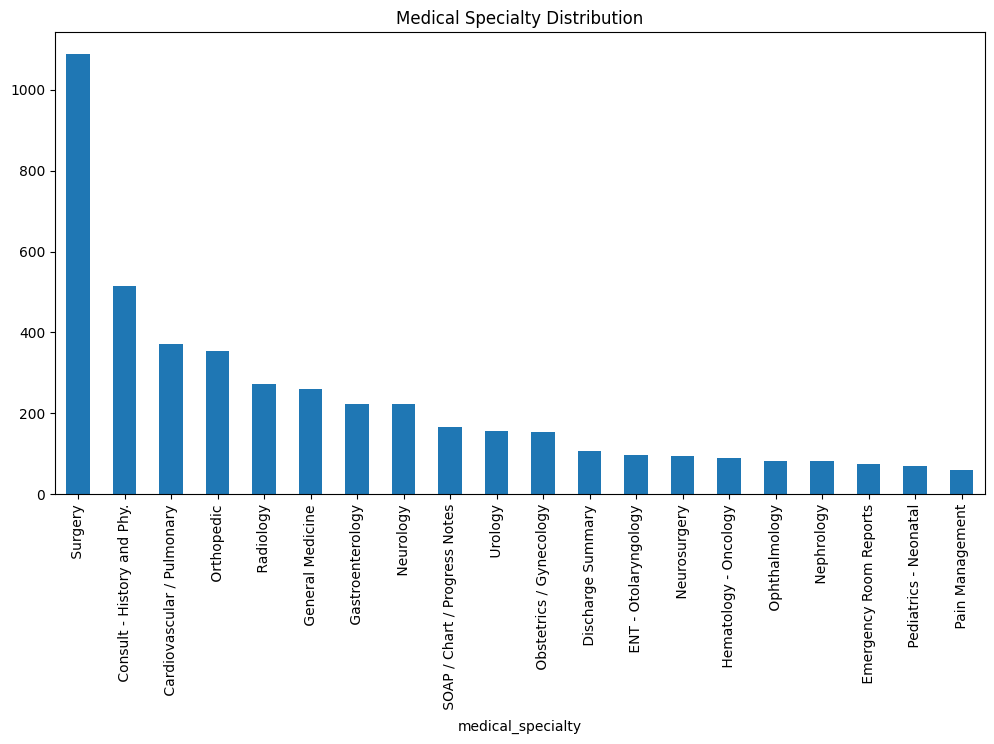

In [6]:
plt.figure(figsize=(12,6))

df["medical_specialty"].value_counts().head(20).plot(
    kind="bar"
)

plt.title("Medical Specialty Distribution")

plt.show()

In [7]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-z ]',' ',text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_text"] = df["transcription"].apply(
    clean_text
)

In [8]:
all_words = " ".join(
    df["clean_text"]
).split()

counter = Counter(all_words)

common_words = counter.most_common(30)

common_df = pd.DataFrame(
    common_words,
    columns=["Word","Frequency"]
)

common_df

,Word,Frequency
0,patient,24208
1,right,11587
2,left,11258
3,history,9509
4,normal,7526
5,procedure,7463
6,placed,7028
7,well,6611
8,pain,5976
9,mg,4375


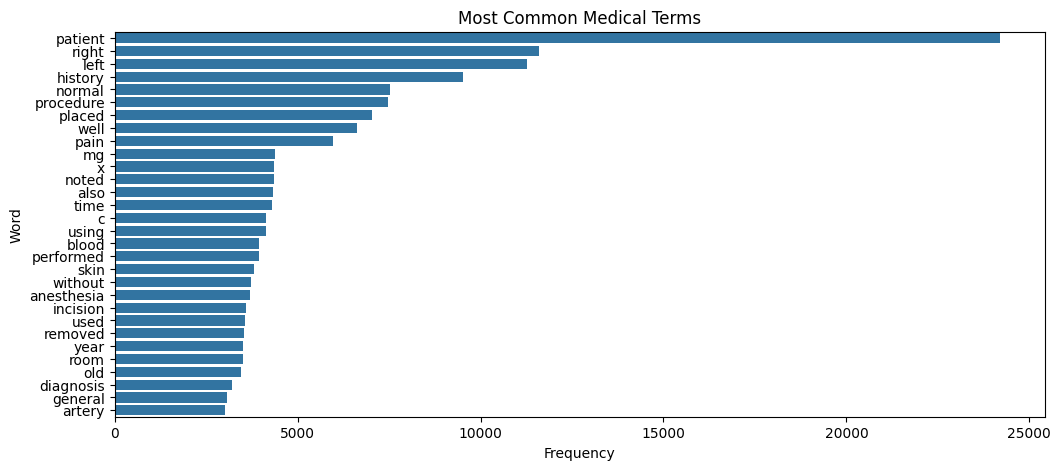

In [9]:
plt.figure(figsize=(12,5))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_df
)

plt.title(
    "Most Common Medical Terms"
)

plt.show()

In [10]:
medical_dictionary = pd.DataFrame(
    counter.items(),
    columns=[
        "Medical Term",
        "Frequency"
    ]
)

medical_dictionary = medical_dictionary.sort_values(
    by="Frequency",
    ascending=False
)

medical_dictionary.head(50)

,Medical Term,Frequency
545,patient,24208
135,right,11587
436,left,11258
95,history,9509
440,normal,7526
526,procedure,7463
549,placed,7028
34,well,6611
123,pain,5976
1162,mg,4375


In [11]:
medical_dictionary.to_csv(
    "medical_dictionary.csv",
    index=False
)

In [12]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["medical_specialty"]
)

num_classes = len(
    encoder.classes_
)

print(num_classes)

40


In [13]:
MAX_WORDS = 20000
MAX_LEN = 250

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df["clean_text"]
)

In [14]:
sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post"
)

y = df["label"].values

In [15]:
sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post"
)

y = df["label"].values

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
baseline = tf.keras.Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        num_classes,
        activation="softmax"
    )
])

C:\Users\spand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
baseline.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
baseline.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_split=0.2
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2524 - loss: 3.1355 - val_accuracy: 0.2956 - val_loss: 2.7719
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3258 - loss: 2.5453 - val_accuracy: 0.3145 - val_loss: 2.5808
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3535 - loss: 2.3537 - val_accuracy: 0.3396 - val_loss: 2.4753
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3828 - loss: 2.1795 - val_accuracy: 0.3358 - val_loss: 2.3689
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3963 - loss: 2.0232 - val_accuracy: 0.3233 - val_loss: 2.2756


In [21]:
inputs = Input(
    shape=(MAX_LEN,)
)

x = Embedding(
    MAX_WORDS,
    128
)(inputs)

attention = MultiHeadAttention(

    num_heads=4,

    key_dim=32

)(
    x,
    x
)

x = LayerNormalization()(
    attention
)

x = GlobalAveragePooling1D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

outputs = Dense(
    num_classes,
    activation="softmax"
)(x)

attention_model = Model(
    inputs,
    outputs
)

In [22]:
attention_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 250, 128)  │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 128)  │     66,048 │ embedding_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 250, 128)  │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 40)        │      5,160 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,647,976 (10.10 MB)

 Trainable params: 2,647,976 (10.10 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
attention_model.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_split=0.2
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.2915 - loss: 2.7374 - val_accuracy: 0.3057 - val_loss: 2.4267
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.3743 - loss: 2.0273 - val_accuracy: 0.2943 - val_loss: 2.0506
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.4394 - loss: 1.5673 - val_accuracy: 0.2679 - val_loss: 2.0872
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.4866 - loss: 1.2838 - val_accuracy: 0.2415 - val_loss: 2.3049
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.5153 - loss: 1.0938 - val_accuracy: 0.1786 - val_loss: 2.4555


In [24]:
def positional_encoding(
    length,
    depth
):

    depth = depth/2

    positions = np.arange(length)[:,np.newaxis]

    depths = np.arange(depth)[np.newaxis,:]/depth

    angle_rates = 1/(10000**depths)

    angle_rads = positions*angle_rates

    pos_encoding = np.concatenate(
        [
            np.sin(angle_rads),
            np.cos(angle_rads)
        ],
        axis=-1
    )

    return pos_encoding

In [25]:
PE = positional_encoding(
    MAX_LEN,
    128
)

PE.shape

(250, 128)

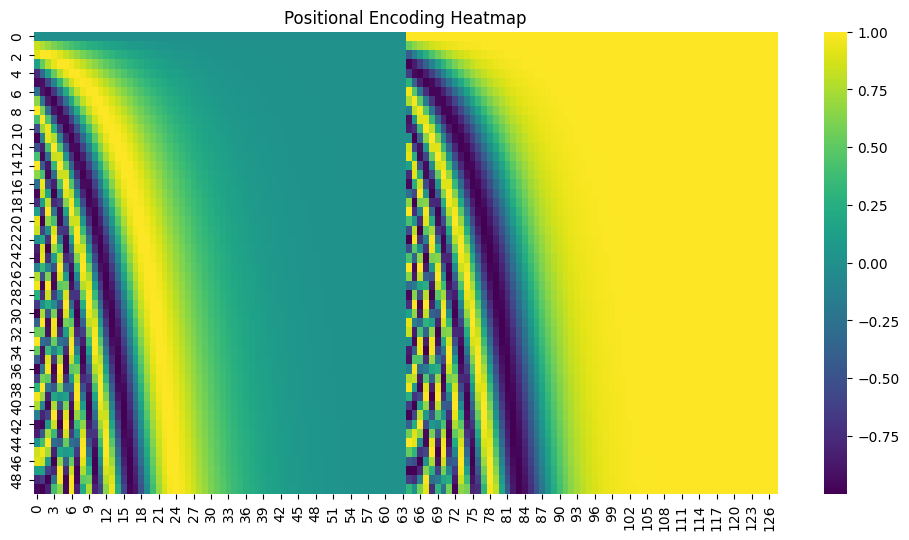

In [26]:
plt.figure(figsize=(12,6))

sns.heatmap(
    PE[:50],
    cmap="viridis"
)

plt.title(
    "Positional Encoding Heatmap"
)

plt.show()

In [28]:
sample_text = df["clean_text"].iloc[0]

sample_seq = tokenizer.texts_to_sequences(
    [sample_text]
)

sample_pad = pad_sequences(
    sample_seq,
    maxlen=MAX_LEN,
    padding="post"
)

pred = attention_model.predict(
    sample_pad
)

idx = np.argmax(pred)

print(
    encoder.inverse_transform(
        [idx]
    )[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
 Psychiatry / Psychology


In [29]:
tokens = sample_text.split()

freq = Counter(tokens)

important = freq.most_common(20)

important

[('allergies', 4),
 ('used', 4),
 ('allegra', 3),
 ('sprays', 3),
 ('prescription', 3),
 ('clear', 3),
 ('zyrtec', 2),
 ('two', 2),
 ('weeks', 2),
 ('well', 2),
 ('nasal', 2),
 ('medication', 2),
 ('think', 2),
 ('erythematous', 2),
 ('without', 2),
 ('subjective', 1),
 ('year', 1),
 ('old', 1),
 ('white', 1),
 ('female', 1)]

In [30]:
import joblib

attention_model.save(
    "attention_model.keras"
)

joblib.dump(
    tokenizer,
    "tokenizer.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

['label_encoder.pkl']